# **Data Pipeline**

## **Data Source:**

[MAESTRO](https://magenta.withgoogle.com/datasets/maestro#v300), is a large-scale dataset of classical piano performances with paired audio and MIDI recordings. It was released by the Magenta team and is widely used in music information retrieval and generative music research as a benchmark. The dataset contains roughly 200 hours of recordings from the International Piano-e-Competition, and each piece is provided with useful metadata such as composer, title, and performance year. The audio is high quality, typically 44.1–48 kHz stereo, while the MIDI provides structured symbolic information such as note onsets, offsets, velocities, and pedal events.

---

Due to the size of the full dataset, preprocessing was performed on a controlled subset of recordings rather than the full archive. Sampling was carried out at the recording level within the official train, validation, and test splits to avoid leakage across clips from the same performance. Recordings were processed sequentially until a target number of fixed-length clips was reached for each split.

In [1]:
import os
import random
import shutil
import uuid
from pathlib import Path
import yaml
import pandas as pd

# audio
import torch
import torchaudio

# plotting
import matplotlib.pyplot as plt

In this pipeline, `data_configs.yaml` within the configs folder, is used to simplify configuration management and centralise all parameter settings.

In [2]:
# load in yaml file 
yaml_path = Path("./configs/data_configs.yaml")

# load config
with open(yaml_path, "r") as f:
    audio_cfg = yaml.safe_load(f)
print(audio_cfg)

{'huggingface': {'processed_repo_id': 'han2o/grant-ortsaem-processed', 'processed_parquet_id': 'han2o/grant-ortsaem-processedV2'}, 'paths': {'raw_dir': './raw', 'raw_data_dir': './raw/maestro-v3.0.0', 'metadata_csv': './raw/maestro-v3.0.0.csv', 'processed_dir': './processed', 'clips_dir': './processed/clips', 'specs_dir': './processed/spectrograms', 'masked_specs_dir': './processed/masked_spectrograms', 'masks_dir': './processed/masks', 'manifests_dir': './processed/manifests', 'output_model_dir': './processed/model', 'output_debug_dir': './processed/debug'}, 'audio': {'sample_rate': 16000, 'mono': True, 'normalise': True, 'clip_duration_seconds': 30.0}, 'spectrogram': {'n_fft': 1024, 'hop_length': 256, 'win_length': 1024, 'n_mels': 128, 'f_min': 30, 'f_max': 8000, 'power': 2.0, 'transform': 'log1p'}, 'masking': {'strategy': 'random_safe', 'gap_seconds_options': [0.5, 2.0, 3.0, 5.0], 'safe_margin_ratio': 0.2, 'fill_value': 0.0}, 'split': {'use_official_maestro_split': True, 'train_name

In [3]:
# creating directories listed in yaml configs
processed_path = audio_cfg["paths"]["processed_dir"]
Path(processed_path).mkdir(parents=True, exist_ok=True)

gap_seconds_options = audio_cfg["masking"]["gap_seconds_options"]
processed_root = Path(processed_path)

# loop through gap seconds
for gaps in gap_seconds_options:
    # create root 
    gap_root = processed_root / str(gaps)
    
    # directories to create
    sub_processed_dirs = {
        "gap_root": gap_root,
        "debug_audio_dir": gap_root / "debug_audio",
        "specs_dir": gap_root / "spectrograms",
        "manifests_dir": gap_root / "manifests",
    }

    for p in sub_processed_dirs.values():
        p.mkdir(parents=True, exist_ok=True)

In [4]:
# loading metadata
metadata_path = Path(audio_cfg["paths"]["metadata_csv"])
metadata_df = pd.read_csv(metadata_path)

print("\n MAETSRO metadata:")
display(metadata_df.head(3))
print(metadata_df.columns.tolist())
# check split distribution
print(metadata_df["split"].value_counts())


 MAETSRO metadata:


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433


['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']
split
train         962
test          177
validation    137
Name: count, dtype: int64


In [5]:
# split metadata
train_name = audio_cfg["split"]["train_name"]
val_name = audio_cfg["split"]["val_name"]
test_name = audio_cfg["split"]["test_name"]

meta_train = metadata_df[metadata_df["split"] == train_name].copy()
meta_val = metadata_df[metadata_df["split"] == val_name].copy()
meta_test = metadata_df[metadata_df["split"] == test_name].copy()

print("Train files:", len(meta_train))
print("Validation files:", len(meta_val))
print("Test files:", len(meta_test))

# shuffle each split before subset sampling
def shuffle_metadata(df, seed=42):
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

meta_train = shuffle_metadata(meta_train)
meta_val = shuffle_metadata(meta_val)
meta_test = shuffle_metadata(meta_test)

Train files: 962
Validation files: 137
Test files: 177


In [6]:
# using the meta data to select one training file to inspect
eg_01 = meta_train.iloc[0]
audio_rel_path = eg_01["audio_filename"]
audio_full_path = Path(audio_cfg["paths"]["raw_data_dir"]) / audio_rel_path

print(audio_full_path)

raw/maestro-v3.0.0/2004/MIDI-Unprocessed_XP_15_R2_2004_01_ORIG_MID--AUDIO_15_R2_2004_02_Track02_wav.wav


In [7]:
# function to load and standardise audio
def load_audio(audio_path, cfg):
    # load audio where waveform shape is [channels, num_samples]
    waveform, sample_rate = torchaudio.load(audio_path)

    # convert to mono by averaging channels
    if cfg["audio"]["mono"] and waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # resample if sample rate differs from target
    # all model inputs must share the same time resolution
    target_sr = cfg["audio"]["sample_rate"]
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate, 
            new_freq=target_sr
            )
        waveform = resampler(waveform)
        sample_rate = target_sr

    # amplitude normalisation: keep amplitude range stable across pieces
    if cfg["audio"]["normalise"]:
        peak = waveform.abs().max()
        if peak > 0:
            waveform = waveform / peak
    return waveform, sample_rate

# chop audio file into fixed-length
def chop2clips(waveform, sample_rate, clip_length):
    clip_num_samples = int(sample_rate * clip_length)
    total_num_samples = waveform.shape[1]
    clips = []
    
    # move through the waveform in non-overlapping chunks
    for start_idx in range(0, total_num_samples, clip_num_samples):
        end_idx = start_idx + clip_num_samples

        # keep only full clips for now
        if end_idx <= total_num_samples:
            clip = waveform[:, start_idx:end_idx]
            clips.append(clip)

    return clips

In [8]:
# function to convert to mel spectrogram
def build_mel(cfg):
    mel_cfg = cfg["spectrogram"]
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=cfg["audio"]["sample_rate"],
        n_fft=mel_cfg["n_fft"],
        win_length=mel_cfg["win_length"],
        hop_length=mel_cfg["hop_length"],
        n_mels=mel_cfg["n_mels"],
        f_min=mel_cfg["f_min"],
        f_max=mel_cfg["f_max"],
        power=mel_cfg["power"],
    )
    return mel_transform

# visualise mel spectrogram
def plot_melspec(mel_spec, title="Mel Spectrogram"):

    # conver to log scale for visibility
    mel_spec_db = torch.log10(mel_spec + 1e-6)

    # remove cannel dimension
    # handle mono or stereo
    if mel_spec_db.ndim == 3:
        if mel_spec_db.shape[0] == 1:
            mel_np = mel_spec_db.squeeze(0).numpy()
        else:
            # average stereo channels into one 2D spectrogram
            mel_np = mel_spec_db.mean(dim=0).numpy()
    else:
        mel_np = mel_spec_db.numpy()
        
    # plot spectrogram
    plt.figure(figsize=(18, 4), dpi=100)
    plt.imshow(mel_np, aspect="auto", origin="lower")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Bins")
    plt.show()

Waveform shape: torch.Size([1, 10918449])
Sample rate: 16000
Number of clips: 22
Single clip shape: torch.Size([1, 480000])
Mel spectrogram shape: torch.Size([1, 128, 1876])


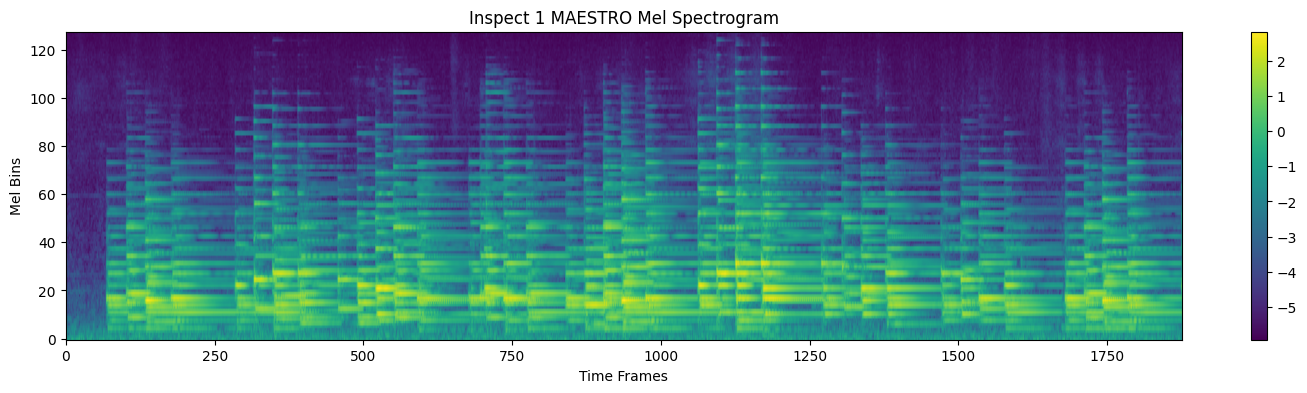

In [9]:
# inspect 1 spectrogram 

# load the one sample waveform from earlier
waveform, sample_rate = load_audio(audio_full_path, audio_cfg)

# chop waveform to clips
clips = chop2clips(
    waveform=waveform,
    sample_rate=sample_rate,
    clip_length=audio_cfg["audio"]["clip_duration_seconds"]
)

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Number of clips:", len(clips))
print("Single clip shape:", clips[0].shape if len(clips) > 0 else "No clips created")

mel_transform = build_mel(audio_cfg)

# example
egmel_01 = mel_transform(clips[0])
print("Mel spectrogram shape:", egmel_01.shape) # [channel dim, mel bins, timeframes]
plot_melspec(egmel_01, title="Inspect 1 MAESTRO Mel Spectrogram")

In [10]:
# masking logic 
def seconds2_framecount(gap_seconds, cfg) -> int:
    sample_rate = cfg["audio"]["sample_rate"]
    hop_length = cfg["spectrogram"]["hop_length"]

    # approximate number of spectrogram frames covered by the gap
    gap_frames = int(round((gap_seconds * sample_rate) / hop_length))
    return max(gap_frames, 1)

# apply masking to spectrogram
def apply_mask(mel_spec, gap_seconds, cfg):
    masked_mel = mel_spec.clone()
    binary_mask = torch.zeros_like(mel_spec)

    # read masking config
    position = cfg["masking"]["strategy"]
    fill_value = cfg["masking"]["fill_value"]
    safe_margin_ratio = cfg["masking"]["safe_margin_ratio"]

    # convert gap length from seconds to spectrogram frames
    gap_frames = seconds2_framecount(gap_seconds, cfg)

    # total numebr of time frames in the spectrogram
    total_frames = mel_spec.shape[-1]

    # center mask
    if position == "center":
        center = total_frames // 2
        start = max(center - gap_frames // 2, 0)
        end = min(start + gap_frames, total_frames)

    # random mask
    elif position == "random":
        max_start = total_frames - gap_frames
        start = random.randint(0, max_start)
        end = start + gap_frames

    # random safe mask
    elif position == "random_safe":
        # margin size in frames
        margin_frames = int(total_frames * safe_margin_ratio)

        # allowed interval for the START of the gap
        min_start = margin_frames
        max_start = total_frames - margin_frames - gap_frames

        # fallback if safe region becomes too small
        if max_start < min_start:
            min_start = 0
            max_start = total_frames - gap_frames

        start = random.randint(min_start, max_start)
        end = start + gap_frames

    # apply mask
    masked_mel[:, :, start:end] = fill_value
    binary_mask[:, :, start:end] = 1.0

    return masked_mel, binary_mask

Original mel shape: torch.Size([1, 128, 1876])
Masked mel shape: torch.Size([1, 128, 1876])
Binary mask shape: torch.Size([1, 128, 1876])


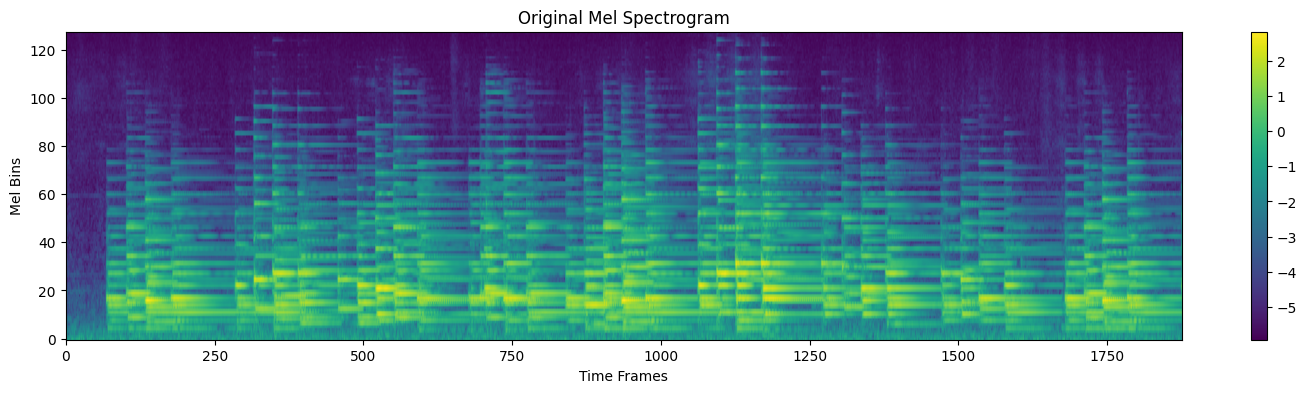

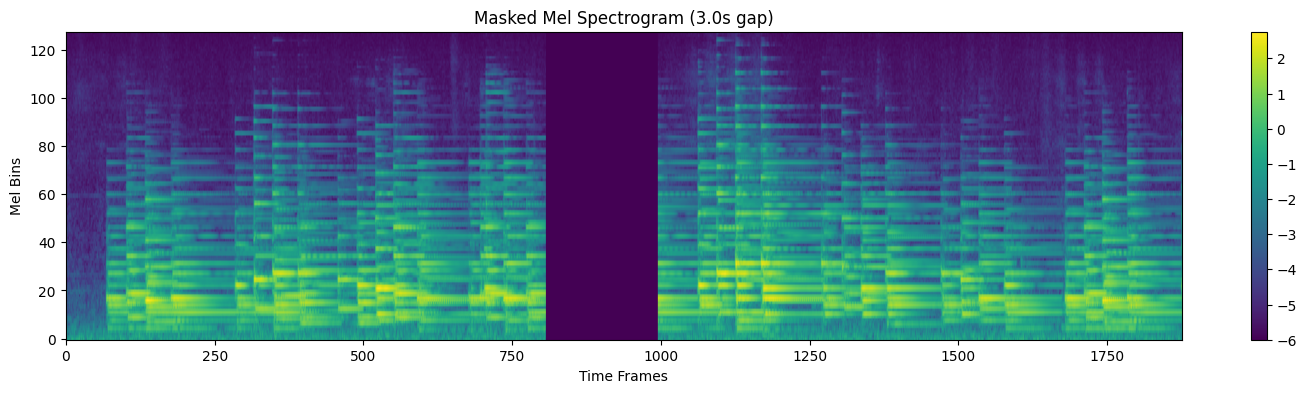

In [11]:
# test masking on a sample
gap_seconds = 3.0
masked_mel, binary_mask = apply_mask(egmel_01, gap_seconds, audio_cfg)

print("Original mel shape:", egmel_01.shape)
print("Masked mel shape:", masked_mel.shape)
print("Binary mask shape:", binary_mask.shape)

# visualise missing portion
plot_melspec(egmel_01, title="Original Mel Spectrogram")
plot_melspec(masked_mel, title=f"Masked Mel Spectrogram ({gap_seconds}s gap)")

In [12]:
# saving output
def save_tensor(tensor, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(tensor, save_path)

# build one example id
def build_egid(split_name, recording_idx, clip_idx):
    return f"{split_name}_rec{recording_idx:05d}_clip{clip_idx:04d}"


In [13]:
# processing one full recording
def one_recording(row, recording_idx, split_name, cfg, mel_transform, gap_seconds, dirs, rng, global_start_idx):
    audio_rel_path = row["audio_filename"]
    audio_full_path = Path(cfg["paths"]["raw_data_dir"]) / audio_rel_path

    waveform, sample_rate = load_audio(audio_full_path, cfg)

    clips = chop2clips(
        waveform=waveform,
        sample_rate=sample_rate,
        clip_length=cfg["audio"]["clip_duration_seconds"]
    )

    manifest_rows = []

    shard_size = 4000
    
    # debug ratio mapping
    ratio_map = {"train": 0.01, "validation": 0.3, "test": 0.3}
    debug_ratio = ratio_map.get(split_name, 0.0)

    for clip_idx, clip in enumerate(clips):
        global_idx = global_start_idx + clip_idx

        gap_tag = str(gap_seconds).replace(".", "p")
        example_id = f"{build_egid(split_name, recording_idx, clip_idx)}_gap{gap_tag}"

        # convert to mel spectrogram
        mel_spec = mel_transform(clip)

        shard_id = global_idx // shard_size
        shard_name = f"shard_{shard_id:04d}"
        shard_dir = dirs["specs_dir"] / shard_name

        # build save path spectrogram
        spec_path = shard_dir / f"{example_id}.{cfg['save']['spectrogram_format']}"
        save_tensor(mel_spec, spec_path)

        # random decision to save raw clip for debugging
        save_debug_clip = rng.random() < debug_ratio
        clip_path = None
        if save_debug_clip:
            clip_path = dirs["debug_audio_dir"] / split_name / f"{example_id}.{cfg['save']['audio_format']}"
            save_tensor(clip, clip_path)

        # manifest row
        manifest_row = {
            "example_id": example_id,
            "split": split_name,
            "recording_idx": recording_idx,
            "clip_idx": clip_idx,
            "audio_filename": audio_rel_path,
            "sample_rate": sample_rate,
            "clip_duration_seconds": cfg["audio"]["clip_duration_seconds"],
            "n_mels": cfg["spectrogram"]["n_mels"],
            "hop_length": cfg["spectrogram"]["hop_length"],
            "spectrogram_path": str(spec_path),
            "debug_clip_saved": save_debug_clip,
            "clip_path": str(clip_path) if clip_path is not None else None,
            "gap_seconds": gap_seconds,
            "shard_id": shard_name,
        }

        manifest_rows.append(manifest_row)

    return manifest_rows

# process each recording untl split count target is reached
def process_until_target(df, split_name, target_clip_count, cfg, gap_seconds, dirs):
    mel_transform = build_mel(cfg)

    all_manifest_rows = []
    total_clips = 0
    recordings_used = 0
    global_clip_counter = 0

    base_seed = 42
    split_seed_offset = {"train": 0, "validation": 1000, "test": 2000}
    rng = random.Random(base_seed + split_seed_offset.get(split_name, 9999))

    for recording_idx, (_, row) in enumerate(df.iterrows()):
        manifest_rows = one_recording(
            row=row,
            recording_idx=recording_idx,
            split_name=split_name,
            cfg=cfg,
            mel_transform=mel_transform,
            gap_seconds=gap_seconds,
            dirs=dirs,
            rng=rng,
            global_start_idx=global_clip_counter
        )

        if len(manifest_rows) == 0:
            continue

        all_manifest_rows.extend(manifest_rows)
        total_clips += len(manifest_rows)
        global_clip_counter += len(manifest_rows)
        recordings_used += 1

        debug_saved_so_far = sum(r["debug_clip_saved"] for r in all_manifest_rows)

        print(
            f"[{split_name} | gap={gap_seconds}] recordings used: {recordings_used} | "
            f"clips so far: {total_clips} | "
            f"debug clips saved: {debug_saved_so_far}"
        )

        if cfg["subset"]["enabled"] and total_clips >= target_clip_count:
            break

    manifest_df = pd.DataFrame(all_manifest_rows)

    # save split manifest inside the correct gap folder
    manifest_path = dirs["manifests_dir"] / f"{split_name}_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False)

    print(f"Saved manifest: {manifest_path}")
    print(
        f"{split_name}: total examples = {len(manifest_df)}, "
        f"debug clips saved = {int(manifest_df['debug_clip_saved'].sum())}"
    )

    return manifest_df

---

## **2. Run Full Processing**

In [14]:
all_gap_results = {}

gap_seconds_options = [0.5, 2.0, 3.0, 5.0]

for gaps in gap_seconds_options:
    print(f"Processing Gap Size: {gaps}")
    gap_root = processed_root / str(gaps)

    sub_processed_dirs = {
        "gap_root": gap_root,
        "debug_audio_dir": gap_root / "debug_audio",
        "specs_dir": gap_root / "spectrograms",
        "manifests_dir": gap_root / "manifests",
    }

    for p in sub_processed_dirs.values():
        p.mkdir(parents=True, exist_ok=True)

    for split_folder in ["train", "validation", "test"]:
        (sub_processed_dirs["debug_audio_dir"] / split_folder).mkdir(parents=True, exist_ok=True)

    train_manifest = process_until_target(
        df=meta_train,
        split_name="train",
        target_clip_count=audio_cfg["subset"]["target_train_clips"],
        cfg=audio_cfg,
        gap_seconds=gaps,
        dirs=sub_processed_dirs
    )

    val_manifest = process_until_target(
        df=meta_val,
        split_name="validation",
        target_clip_count=audio_cfg["subset"]["target_val_clips"],
        cfg=audio_cfg,
        gap_seconds=gaps,
        dirs=sub_processed_dirs
    )

    test_manifest = process_until_target(
        df=meta_test,
        split_name="test",
        target_clip_count=audio_cfg["subset"]["target_test_clips"],
        cfg=audio_cfg,
        gap_seconds=gaps,
        dirs=sub_processed_dirs
    )

    all_gap_results[gaps] = {
        "dirs": sub_processed_dirs,
        "train_manifest": train_manifest,
        "val_manifest": val_manifest,
        "test_manifest": test_manifest,
    }

    print("\nProcessing complete.")
    print("Train examples:", len(train_manifest))
    print("Validation examples:", len(val_manifest))
    print("Test examples:", len(test_manifest))

Processing Gap Size: 0.5
[train | gap=0.5] recordings used: 1 | clips so far: 22 | debug clips saved: 1
[train | gap=0.5] recordings used: 2 | clips so far: 48 | debug clips saved: 1
[train | gap=0.5] recordings used: 3 | clips so far: 72 | debug clips saved: 1
[train | gap=0.5] recordings used: 4 | clips so far: 83 | debug clips saved: 1
[train | gap=0.5] recordings used: 5 | clips so far: 156 | debug clips saved: 2
[train | gap=0.5] recordings used: 6 | clips so far: 162 | debug clips saved: 2
[train | gap=0.5] recordings used: 7 | clips so far: 183 | debug clips saved: 2
[train | gap=0.5] recordings used: 8 | clips so far: 190 | debug clips saved: 2
[train | gap=0.5] recordings used: 9 | clips so far: 196 | debug clips saved: 2
[train | gap=0.5] recordings used: 10 | clips so far: 210 | debug clips saved: 2
[train | gap=0.5] recordings used: 11 | clips so far: 244 | debug clips saved: 2
[train | gap=0.5] recordings used: 12 | clips so far: 248 | debug clips saved: 2
[train | gap=0.5

---

# 

## **3. Hugging Face Uploading**

In [28]:
# hugging face
from huggingface_hub import HfApi

/Users/ngjunhan/opt/anaconda3/envs/dl_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# write readme for dataset repository

# readme file for raw
raw_readme = """# **MAESTRO Raw Mirror**

This repository contains the raw MAESTRO directory structure used in a project data pipeline.

## **Contents:**
- Year folders of MAESTRO audio
- Original metadata files
- Original license file

## **Note**
This repository mirrors the local MAESTRO dataset structure for research workflow use.
Please preserve the original attribution and licensing associated with MAESTRO.
"""

# readme file under processed
processed_readme = """# **Processed MAESTRO for Music Inpainting**

This repository contains processed outputs derived from MAESTRO.

## **Contents:**
- `clips/`: saved clip files
- `spectrograms/`: mel spectrogram tensors
- `masked_spectrograms/`: masked mel spectrogram tensors
- `masks/`: binary masks
- `manifests/`: train / validation / test CSV manifests

## **Pipeline summary:**
1. Load raw MAESTRO audio
2. Optionally convert to mono/studio
3. Resample to target sample rate
4. Normalise waveform
5. Chop into fixed-length clips
6. Convert clips to mel spectrograms
7. Apply masking
8. Save outputs and manifests

## **Important note**
Clips are stored as `.pt` files, they are downloadable but not directly previewable as Hub audio examples.
"""

# assign raw and processed paths
raw_root = Path(audio_cfg["paths"]["raw_dir"])
processed_root = Path(audio_cfg["paths"]["processed_dir"])
print(raw_root)
print(processed_root)

# write readme text
raw_path = Path(raw_root / "README.md")
raw_path.write_text(raw_readme, encoding="utf-8")
print(f"Wrote: {raw_path}")

# write read me text
processed_path = Path(processed_root / "README.md")
processed_path.write_text(processed_readme, encoding="utf-8")
print(f"Wrote: {processed_path}")


raw
processed
Wrote: raw/README.md
Wrote: processed/README.md


In [ ]:
# upload holder to huffing face
def upload_folder(folder_path, repo_id):
    api = HfApi()

    # using upload large folder
    api.upload_large_folder(
        folder_path=folder_path,
        repo_id=repo_id,
        repo_type="dataset"
        )

    print(f"Uploaded {folder_path} to https://huggingface.co/datasets/{repo_id}")

In [ ]:
hf_cfg = audio_cfg.get("huggingface", {})
raw_repo_id = hf_cfg["raw_repo_id"]
processed_repo_id = hf_cfg["processed_repo_id"]

In [ ]:
# upload processed folder
upload_folder(str(processed_root,), repo_id=processed_repo_id)

In [ ]:
# upload root folder
upload_folder(str(raw_root), repo_id=processed_repo_id)

----